主要是股票绘图

In [40]:
import matplotlib
# 因为是在jupyter中，所以需要添加下边的
%matplotlib inline 
# matplotlib.use('agg')  # 后台显示，jupyter中需要保存图片的时候用到
# matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
import  mplfinance as mpf
import talib

import numpy as np

import sys
sys.path.append('../../DataSource/baostock')
import datasource

In [27]:
_codes = datasource.get_codes()
# 我这里只是演示
_code = _codes[0]
_dt = datasource.get_data(_code)


In [28]:
# 实现自定义颜色和风格
my_color = mpf.make_marketcolors(
    up='r', # 上涨颜色
    down='g', # 下跌颜色
    edge='inherit', # 边框使用主配色
    wick='inherit',
    volume='inherit')
my_style = mpf.make_mpf_style(
    marketcolors=my_color,
    figcolor='(0.82,0.83,0.85)',
    gridcolor='(0.82,0.83,0.85)'
)


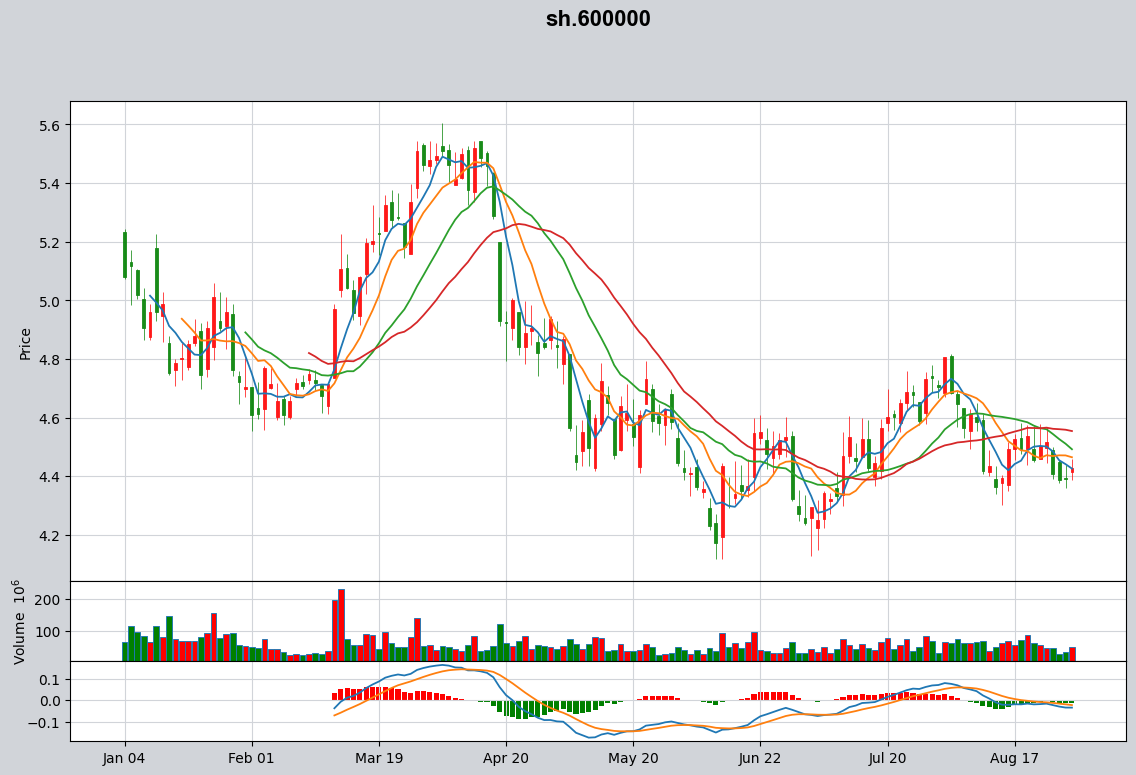

In [42]:
# 这里创建画布
fig = mpf.figure(style=my_style, figsize=(12,8),facecolor=(0.82, 0.83, 0.85))
# 添加3个图表,4个数字代表左下角在figure中的坐标以及宽和高，坐标系的原点是左下角的
ax1 = fig.add_axes([0.06,0.25, 0.88,0.60])
ax2 = fig.add_axes([0.06,0.15, 0.88,0.10], sharex=ax1) # 共用x轴
ax3 = fig.add_axes([0.06,0.05, 0.88,0.10], sharex=ax1)
# 设置标签
ax1.set_ylabel('price')
ax1.set_ylabel('volume')
ax1.set_ylabel('macd')
# 显示文本
title_font = {
    'fontname':'Arial',
    'size':16,
    'color':'black',
    'weight':'bold',
    'va':'bottom',
    'ha':'center'
} # 定制文本的字体
fig.text(0.50,0.94, _code,**title_font)
# 添加平均线
ma_s = [5,10,20,30]
for ma in ma_s:
    _dt[f'MA{ma}'] = talib.SMA(_dt['close'], timeperiod=ma)
ma_s2 = [f'MA{i}' for i in ma_s]
# 然后添加macd
_dt['macd'], _dt['signal'], _dt['hist'] = talib.MACD(_dt['close'], fastperiod=12, slowperiod=26, signalperiod=9)

# 只是绘制指定个数的数据
plot_data = _dt.iloc[:150,:]
# 追加的指标是个列表
ap = []
ap.append(mpf.make_addplot(plot_data[ma_s2], ax=ax1))  # 均线的
# 追加macd
ap.append(mpf.make_addplot(plot_data[['macd', 'signal']], ax=ax3))
bar_r = np.where(plot_data['hist']>0 ,plot_data['hist'],0)
bar_g = np.where(plot_data['hist']<=0 ,plot_data['hist'],0)
# 使用柱状图
ap.append(mpf.make_addplot(bar_r,type='bar', color='red', ax=ax3)) 
ap.append(mpf.make_addplot(bar_g,type='bar', color='green', ax=ax3)) 

mpf.plot(
    plot_data, 
    ax=ax1, 
    volume=ax2, 
    addplot=ap,
    type='candle', 
    style=my_style)
# fig.show() # 因为在jupyter中，这里不需要调用，会直接显示的。
